##1. Mount Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##2. Imports

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

##3. Dataset Paths

In [ ]:
PROCESSED_PATH = Path(
    "/content/drive/MyDrive/Dissertation/Dataset/Processed"
)

metadata_file = (
    PROCESSED_PATH /
    "nodule_dataset.csv"
)

##4. Load Dataset

In [ ]:
dataset = pd.read_csv(metadata_file)

print(dataset.shape)

dataset.head()

(23, 10)


,PatientID,NoduleID,PatchPath,PatchShape,Readers,MeanMalignancy,MedianMalignancy,CancerLabel,MaskedPatchPath,MaskPath
0,LIDC-IDRI-0001,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(52, 44, 9)",4,4.75,5.0,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...
1,LIDC-IDRI-0002,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(45, 50, 28)",2,4.50,4.5,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...
2,LIDC-IDRI-0003,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(36, 34, 8)",1,2.00,2.0,0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...
3,LIDC-IDRI-0003,2,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(40, 45, 10)",4,4.25,4.5,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...
4,LIDC-IDRI-0003,3,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(13, 19, 4)",4,3.25,3.5,0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...


##5. Verify Files

In [ ]:
missing = []

for path in dataset["PatchPath"]:

    if not os.path.exists(path):

        missing.append(path)

print("Missing patches:", len(missing))

Missing patches: 0


##6. Analyze Patch Sizes

In [ ]:
sizes = []

for path in dataset["PatchPath"]:

    patch = np.load(path)

    sizes.append(patch.shape)

sizes = np.array(sizes)

sizes[:10]

array([[52, 44,  9],
       [45, 50, 28],
       [36, 34,  8],
       [40, 45, 10],
       [13, 19,  4],
       [20, 19,  8],
       [11, 11,  5],
       [10, 10,  2],
       [14, 14,  3],
       [ 9, 11,  2]])

##7. Basic Statistics

In [ ]:
print("Height")

print("Min :", sizes[:,0].min())
print("Max :", sizes[:,0].max())
print("Mean:", sizes[:,0].mean())

print()

print("Width")

print("Min :", sizes[:,1].min())
print("Max :", sizes[:,1].max())
print("Mean:", sizes[:,1].mean())

print()

print("Depth")

print("Min :", sizes[:,2].min())
print("Max :", sizes[:,2].max())
print("Mean:", sizes[:,2].mean())

Height
Min : 7
Max : 53
Mean: 20.130434782608695

Width
Min : 6
Max : 50
Mean: 20.08695652173913

Depth
Min : 1
Max : 28
Mean: 6.130434782608695


##8. Histograms

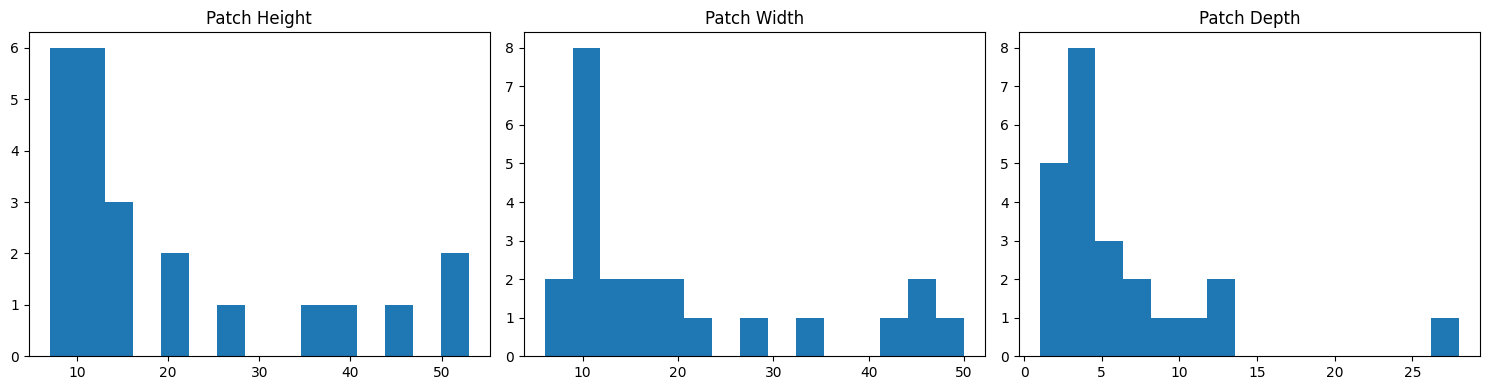

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(sizes[:,0], bins=15)
plt.title("Patch Height")

plt.subplot(1,3,2)
plt.hist(sizes[:,1], bins=15)
plt.title("Patch Width")

plt.subplot(1,3,3)
plt.hist(sizes[:,2], bins=15)
plt.title("Patch Depth")

plt.tight_layout()

plt.show()

##9. Find the Largest Patch

In [ ]:
largest = np.argmax(
    sizes.prod(axis=1)
)

print(dataset.iloc[largest])

print()

print("Shape:", sizes[largest])

PatientID                                              LIDC-IDRI-0002
NoduleID                                                            1
PatchPath           /content/drive/MyDrive/Dissertation/Dataset/Pr...
PatchShape                                               (45, 50, 28)
Readers                                                             2
MeanMalignancy                                                    4.5
MedianMalignancy                                                  4.5
CancerLabel                                                         1
MaskedPatchPath     /content/drive/MyDrive/Dissertation/Dataset/Pr...
MaskPath            /content/drive/MyDrive/Dissertation/Dataset/Pr...
Name: 1, dtype: object

Shape: [45 50 28]


##10. Imports
####Now we'll begin converting the 3D patches into standardized CNN inputs.

In [ ]:
import cv2
import numpy as np

##13. Create Output Folder

In [ ]:
CNN_PATH = (
    PROCESSED_PATH /
    "CNN_Input"
)

CNN_PATH.mkdir(
    exist_ok=True,
    parents=True
)

##14. HU Normalization Funcation
####We'll clip intensities to a lung window and scale them to 0–255.

In [ ]:
def normalize_hu(image):

    image = np.clip(image, -1000, 400)

    image = (image + 1000) / 1400

    image = image * 255

    return image.astype(np.uint8)

In [ ]:
def largest_mask_slice(mask):
    """
    Returns the slice index containing the largest
    segmented nodule area.
    """

    areas = []

    for i in range(mask.shape[2]):
        areas.append(np.sum(mask[:, :, i]))

    return int(np.argmax(areas))

###15. Convert One 3D Patch to a 3-Channel Image

In [ ]:
import cv2
import numpy as np

def create_rgb_patch(patch, mask):
    """
    Creates a CNN-ready RGB image from the slice
    containing the largest segmented nodule.
    """

    # Select best slice
    slice_idx = largest_mask_slice(mask)

    image = patch[:, :, slice_idx]

    image = normalize_hu(image)

    image = cv2.resize(
        image,
        (224, 224),
        interpolation=cv2.INTER_LANCZOS4
    )

    image = (image * 255).astype(np.uint8)

    rgb = np.stack(
        [image, image, image],
        axis=-1
    )

    return rgb

##16. Test on One Patch

In [ ]:
patch = np.load(dataset.iloc[0]["PatchPath"])
mask = np.load(dataset.iloc[0]["MaskPath"])

rgb = create_rgb_patch(patch, mask)

print(rgb.shape)

(224, 224, 3)


##17. Visualize the RGB Representation

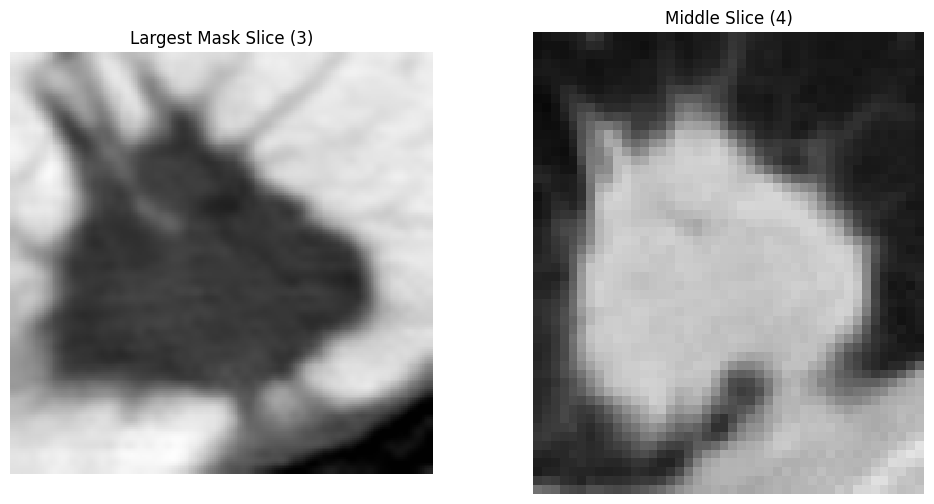

In [ ]:
best = largest_mask_slice(mask)
middle = patch.shape[2] // 2

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(create_rgb_patch(patch, mask), interpolation="nearest")
plt.title(f"Largest Mask Slice ({best})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    np.stack([
        normalize_hu(patch[:,:,middle]),
        normalize_hu(patch[:,:,middle]),
        normalize_hu(patch[:,:,middle])
    ], axis=-1)
)
plt.title(f"Middle Slice ({middle})")
plt.axis("off")

plt.show()